In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib

#For asking file names
import tkinter as tk
from tkinter import filedialog
root = tk.Tk()
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)

''

In [129]:
scan_dir = tk.filedialog.askdirectory()
print(scan_dir)
scan_path = pathlib.Path(scan_dir)
snr_paths = list(scan_path.rglob("*SNR_test_resize_profile.csv"))
stitch_paths = list(scan_path.rglob("*stitch_process.csv"))
bg_paths = list(scan_path.rglob("*Bg_process.csv"))

print(stitch_paths, len(stitch_paths))
print(snr_paths)

C:/Users/jeppe/Desktop/Work Stuffs/Data Sets/LIPI_Paper
[WindowsPath('C:/Users/jeppe/Desktop/Work Stuffs/Data Sets/LIPI_Paper/1521/stitch_process.csv'), WindowsPath('C:/Users/jeppe/Desktop/Work Stuffs/Data Sets/LIPI_Paper/20260618_131243/stitch_process.csv'), WindowsPath('C:/Users/jeppe/Desktop/Work Stuffs/Data Sets/LIPI_Paper/20260618_143832/stitch_process.csv'), WindowsPath('C:/Users/jeppe/Desktop/Work Stuffs/Data Sets/LIPI_Paper/20260618_144430/stitch_process.csv')] 4
[WindowsPath('C:/Users/jeppe/Desktop/Work Stuffs/Data Sets/LIPI_Paper/1521/SNR_test_resize_profile.csv'), WindowsPath('C:/Users/jeppe/Desktop/Work Stuffs/Data Sets/LIPI_Paper/20260618_131243/SNR_test_resize_profile.csv'), WindowsPath('C:/Users/jeppe/Desktop/Work Stuffs/Data Sets/LIPI_Paper/20260618_143832/SNR_test_resize_profile.csv'), WindowsPath('C:/Users/jeppe/Desktop/Work Stuffs/Data Sets/LIPI_Paper/20260618_144430/SNR_test_resize_profile.csv')]


C:\Users\jeppe\Desktop\Work Stuffs\Data Sets\LIPI_Paper\1521\stitch_process.csv
C:\Users\jeppe\Desktop\Work Stuffs\Data Sets\LIPI_Paper\20260618_131243\stitch_process.csv
C:\Users\jeppe\Desktop\Work Stuffs\Data Sets\LIPI_Paper\20260618_143832\stitch_process.csv
C:\Users\jeppe\Desktop\Work Stuffs\Data Sets\LIPI_Paper\20260618_144430\stitch_process.csv
123.76867521082913
C:\Users\jeppe\Desktop\Work Stuffs\Data Sets\LIPI_Paper\1521\stitch_process.csv
(766,) (766, 640) (640,)


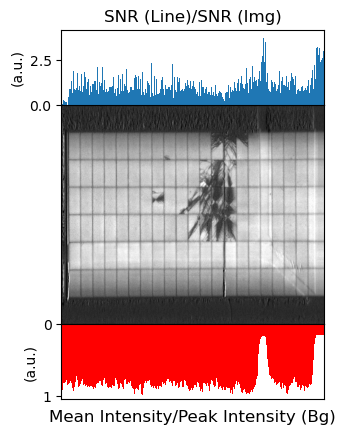

C:\Users\jeppe\Desktop\Work Stuffs\Data Sets\LIPI_Paper\20260618_131243\stitch_process.csv
(766,) (766, 640) (640,)


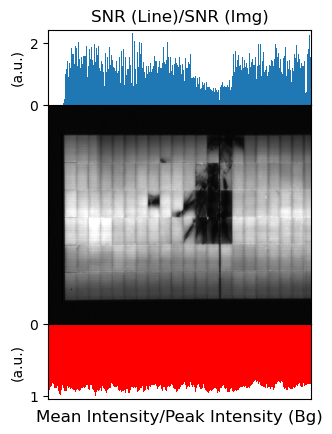

C:\Users\jeppe\Desktop\Work Stuffs\Data Sets\LIPI_Paper\20260618_143832\stitch_process.csv
(766,) (766, 640) (640,)


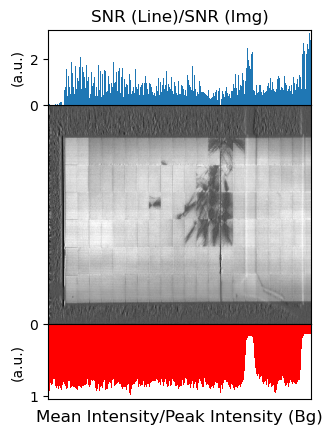

C:\Users\jeppe\Desktop\Work Stuffs\Data Sets\LIPI_Paper\20260618_144430\stitch_process.csv
(766,) (766, 640) (640,)


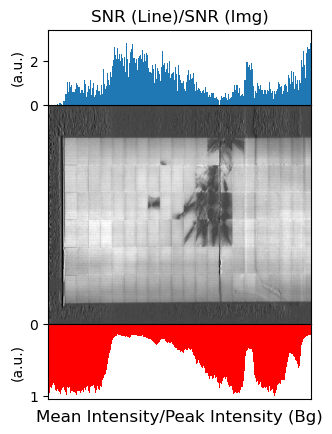

In [153]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

snrs = list()
for path in stitch_paths:
    print(path)

    img = np.loadtxt(path, delimiter=",")
    snrs.append(np.mean(img[:,100:540])/np.std(img[:,0:75], ddof=1))

snr_scale = np.max(snrs)
print(snr_scale)

for i in range(4):
    stitch_path = stitch_paths[i]
    snr_path = snr_paths[i]

    print(stitch_path)

    stitch = np.loadtxt(stitch_path, delimiter=",")
    snr_scale = np.mean(stitch[:,100:540])/np.std(stitch[:,0:75], ddof=1)

    snr_prof_lines = np.loadtxt(snr_path, delimiter=",")/snr_scale
    snr_prof_cols = np.mean(stitch[60:],axis=0)/np.std(stitch[:35],axis=0, ddof=1)

    print(snr_prof_lines.shape, stitch.shape, snr_prof_cols.shape)

    # 1. Opret kun ét subplot til billedet (så aspektforholdet styres herfra)
    fig, img = plt.subplots()
    im = img.imshow(stitch.transpose(), cmap="gray")
    img.xaxis.set_visible(False)
    img.yaxis.set_visible(False)

    #img.set_xlim(0, 640)
    #img.set_ylim(766,0)

    # 2. Skab en akse-opdeler baseret på billed-plottet
    divider = make_axes_locatable(img)

    # 3. Tilføj profil-plottet på højre side ("right").
    # "size" bestemmer bredden af din bar-graf (f.eks. 30% af billedets bredde).
    # "pad" er afstanden mellem de to plots (0 fjerner al luft).
    profile_lines = divider.append_axes("top", size=0.75, pad=0, sharex=img)

    mean_intens = divider.append_axes("bottom", size=0.75, pad=0, sharex=img)
    #profile_cols = divider.append_axes("top", size=0.75, pad=0, sharex=img)

    # 4. Tegn din vandrette bar-graf
    profile_lines.bar(range(len(snr_prof_lines)), snr_prof_lines.clip(0), width=1)
    #profile_lines.set_xlim(0, 2*snr_scale)
    #profile_lines.vlines(snr_scale, 0, 765, "r")
    profile_lines.xaxis.set_visible(False)
    #profile_lines.xaxis.set_label("Test")
    profile_lines.set_title("SNR (Line)/SNR (Img)")
    profile_lines.set_ylabel("(a.u.)")
    #profile_cols.bar(range(len(snr_prof_cols)), snr_prof_cols.clip(0), width=1)
    #profile_cols.yaxis.set_visible(False)

    bg = np.loadtxt(bg_paths[i], delimiter=",")
    mean_intens_data = np.mean(bg[:, 0:75], axis=1)
    test = mean_intens_data
    mean_intens.bar(range(766), mean_intens_data/mean_intens_data.max(), width=1, color="r")
    mean_intens.xaxis.set_visible(False)
    #mean_intens.yaxis.set_visible(False)
    mean_intens.yaxis.set_inverted(True)
    mean_intens.set_title("Mean Intensity/Peak Intensity (Bg)", y=-0.4)
    mean_intens.set_ylabel("(a.u.)")
    #mean_intens.set_ylabel("SNR")

    # Skjul y-aksen på profil-plottet
    #profile_lines.yaxis.set_visible(False)
    #profile_cols.xaxis.set_visible(False)

    plt.show()
